<a href="https://colab.research.google.com/github/Ozk18532/INTELIGENCIA-COMPUTACIONAL-Oscar-Mercado/blob/main/Transfer_Learning_y_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Dispositivo: cpu


In [12]:
import os

data_dir = "/content/drive/MyDrive/Data"

In [13]:
weights_resnet = models.ResNet18_Weights.DEFAULT
weights_mobilenet = models.MobileNet_V2_Weights.DEFAULT

# Usaremos las mismas transforms de ImageNet para ambos experimentos
transform = weights_resnet.transforms()
print(transform)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [14]:
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Clases:", class_names)
print("Número de clases:", num_classes)
print("Total de imágenes:", len(full_dataset))

Clases: ['Aura', 'Maya', 'Nala', 'dog ']
Número de clases: 4
Total de imágenes: 180


In [15]:
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 144
Validation: 18
Test: 18


In [16]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

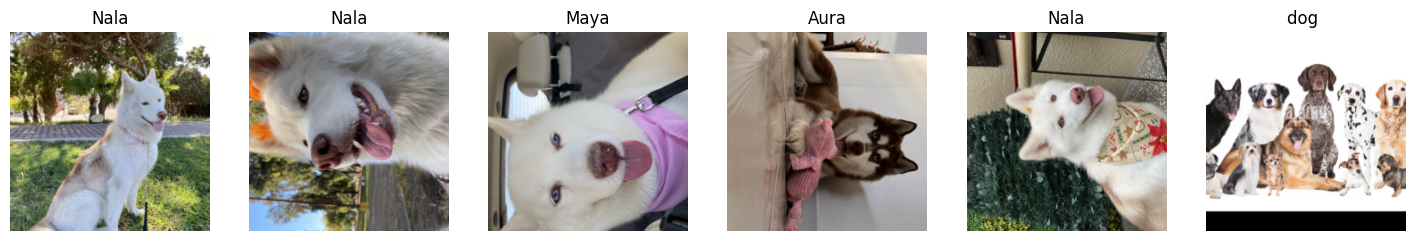

In [17]:
def denormalize(img_tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor * std + mean

def show_batch(loader, class_names, max_images=6):
    images, labels = next(iter(loader))
    images = images[:max_images]
    labels = labels[:max_images]

    fig, axes = plt.subplots(1, len(images), figsize=(18, 4))
    if len(images) == 1:
        axes = [axes]

    for i in range(len(images)):
        img = denormalize(images[i].cpu(), [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        img = torch.clamp(img, 0, 1)
        axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis("off")

    plt.show()

show_batch(train_loader, class_names)

In [18]:
def build_resnet_transfer(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

def build_resnet_finetune(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

def build_mobilenet_transfer(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

def build_mobilenet_finetune(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    for param in model.features[-1].parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model.to(device)

In [19]:
def compute_accuracy(outputs, labels):
    preds = outputs.argmax(dim=1)
    correct = (preds == labels).sum().item()
    return correct

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_correct += compute_accuracy(outputs, labels)
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

In [21]:
def evaluate_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_correct += compute_accuracy(outputs, labels)
            total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

In [22]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    model.load_state_dict(best_weights)
    return model, history, best_val_acc

In [23]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [24]:
epochs = 10
criterion = nn.CrossEntropyLoss()

results = {}

In [ ]:
model_resnet_tl = build_resnet_transfer(num_classes)
optimizer_resnet_tl = torch.optim.Adam(model_resnet_tl.fc.parameters(), lr=1e-3)

model_resnet_tl, history_resnet_tl, best_val_resnet_tl = train_model(
    model_resnet_tl, train_loader, val_loader, criterion, optimizer_resnet_tl, epochs=epochs
)

results["ResNet18_Transfer"] = {
    "model": model_resnet_tl,
    "history": history_resnet_tl,
    "best_val_acc": best_val_resnet_tl
}

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10 | Train Loss: 1.1768 | Train Acc: 0.4931 | Val Loss: 1.1555 | Val Acc: 0.3889
Epoch 2/10 | Train Loss: 0.9034 | Train Acc: 0.6111 | Val Loss: 0.8915 | Val Acc: 0.6667
Epoch 3/10 | Train Loss: 0.7158 | Train Acc: 0.7847 | Val Loss: 0.7514 | Val Acc: 0.7222
Epoch 4/10 | Train Loss: 0.5682 | Train Acc: 0.8819 | Val Loss: 0.6899 | Val Acc: 0.8333
Epoch 5/10 | Train Loss: 0.4937 | Train Acc: 0.9167 | Val Loss: 0.6226 | Val Acc: 0.7778


In [ ]:
model_resnet_ft = build_resnet_finetune(num_classes)
optimizer_resnet_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet_ft.parameters()),
    lr=1e-5
)

model_resnet_ft, history_resnet_ft, best_val_resnet_ft = train_model(
    model_resnet_ft, train_loader, val_loader, criterion, optimizer_resnet_ft, epochs=epochs
)

results["ResNet18_FineTuning"] = {
    "model": model_resnet_ft,
    "history": history_resnet_ft,
    "best_val_acc": best_val_resnet_ft
}

In [ ]:
model_mobilenet_tl = build_mobilenet_transfer(num_classes)
optimizer_mobilenet_tl = torch.optim.Adam(model_mobilenet_tl.classifier[1].parameters(), lr=1e-3)

model_mobilenet_tl, history_mobilenet_tl, best_val_mobilenet_tl = train_model(
    model_mobilenet_tl, train_loader, val_loader, criterion, optimizer_mobilenet_tl, epochs=epochs
)

results["MobileNetV2_Transfer"] = {
    "model": model_mobilenet_tl,
    "history": history_mobilenet_tl,
    "best_val_acc": best_val_mobilenet_tl
}

In [ ]:
model_mobilenet_ft = build_mobilenet_finetune(num_classes)
optimizer_mobilenet_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_mobilenet_ft.parameters()),
    lr=1e-5
)

model_mobilenet_ft, history_mobilenet_ft, best_val_mobilenet_ft = train_model(
    model_mobilenet_ft, train_loader, val_loader, criterion, optimizer_mobilenet_ft, epochs=epochs
)

results["MobileNetV2_FineTuning"] = {
    "model": model_mobilenet_ft,
    "history": history_mobilenet_ft,
    "best_val_acc": best_val_mobilenet_ft
}

In [ ]:
for model_name, info in results.items():
    plot_history(info["history"], model_name)

In [ ]:
for model_name, info in results.items():
    print(f"{model_name}: best validation accuracy = {info['best_val_acc']:.4f}")

In [ ]:
best_model_name = max(results, key=lambda k: results[k]["best_val_acc"])
best_model = results[best_model_name]["model"]

print("Mejor modelo:", best_model_name)
print("Best validation accuracy:", results[best_model_name]["best_val_acc"])

In [ ]:
def predict_on_loader(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()

            y_true.extend(labels.numpy())
            y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

In [ ]:
y_true, y_pred = predict_on_loader(best_model, test_loader)

In [ ]:
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("Matriz de confusión:")
print(cm)

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [ ]:
save_path = "/content/drive/MyDrive/best_dog_model.pth"
torch.save(best_model.state_dict(), save_path)
print("Modelo guardado en:", save_path)

In [ ]:
# =========================
# PREDICCIÓN DE UNA IMAGEN
# =========================

import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt

# -------- CONFIG --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# IMPORTANTE: define tus clases en el mismo orden que entrenamiento
class_names = ["black labrador", "chihuahua dog", "husky dog"]
num_classes = len(class_names)

# -------- CARGAR MODELO --------
def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_model(num_classes)
model.load_state_dict(torch.load("/content/drive/MyDrive/best_dog_model.pth", map_location=device))
model = model.to(device)
model.eval()

# -------- TRANSFORMACIONES --------
weights = models.ResNet18_Weights.DEFAULT
transform = weights.transforms()

# -------- FUNCIÓN DE PREDICCIÓN --------
def predict_image(image_path, model, class_names, threshold=0.6):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    pred_idx = probs.argmax()
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx]

    # lógica de desconocido
    if confidence < threshold:
        pred_class = "desconocido"

    return pred_class, confidence, probs, image

# -------- USO --------
image_path = "/content/drive/MyDrive/test.jpg"

pred_class, confidence, probs, image = predict_image(image_path, model, class_names)

print("Predicción:", pred_class)
print("Confianza:", confidence)
print("Probabilidades:", probs)

# -------- VISUALIZACIÓN --------
plt.imshow(image)
plt.title(f"Predicción: {pred_class} ({confidence:.2f})")
plt.axis("off")
plt.show()